# Set environment

In [20]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### keras
from keras            import Sequential, models, layers
from keras.utils      import to_categorical
from keras.optimizers import SGD, Adam

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"

In [2]:
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

### restrict the memory usage of tensorflow
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
k.tensorflow_backend.set_session(tf.Session(config=config))

# Load data

In [3]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

wrap01_data.P		wrap03_subs_1e4_N10.P	wrap05_img_1e4_var02.P
wrap02_scaled_k0.P	wrap04_tsne_1e4_N10.P	wrap05_img_1e4_var05.P
wrap03_subs_1e4_N100.P	wrap05_img_1e4_var01.P	wrap05_img_1e4_var10.P


In [4]:
###
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v01 = pickle.load(file)
file.close()

###
fname = "wrap05_img_1e4_var02.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v02 = pickle.load(file)
file.close()

###
fname = "wrap05_img_1e4_var05.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v05 = pickle.load(file)
file.close()

###
fname = "wrap05_img_1e4_var10.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_v10 = pickle.load(file)
file.close()

# Split data

In [5]:
dat_img = wrap_tsne_v10
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 9, 10)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 90, 1: 90, 2: 90})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
    1: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]
    2: [180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251
 252 253

# get image

In [11]:
img_train = dat_img_train.img
img_train = img_train.reshape((270, 128, 128, 14))

y_train = dat_img_train.label
y_train = to_categorical(y_train)

print(img_train.shape)
print(y_train.shape)

(270, 128, 128, 14)
(270, 3)


In [12]:
img_test = dat_img_test.img
img_test = img_test.reshape((60, 128, 128, 14))

y_test = dat_img_test.label
y_test = to_categorical(y_test)

print(img_test.shape)
print(y_test.shape)

(60, 128, 128, 14)
(60, 3)


# Visualize

In [13]:
indice = [dat_img_train.which_label(idx)[:3] for idx in range(3)]
indice = np.concatenate(indice)
indice

array([  0,   1,   2,  90,  91,  92, 180, 181, 182])

In [14]:
dat_img_train.img.shape

(270, 16384, 14)

In [16]:
img_train.shape

(270, 128, 128, 14)

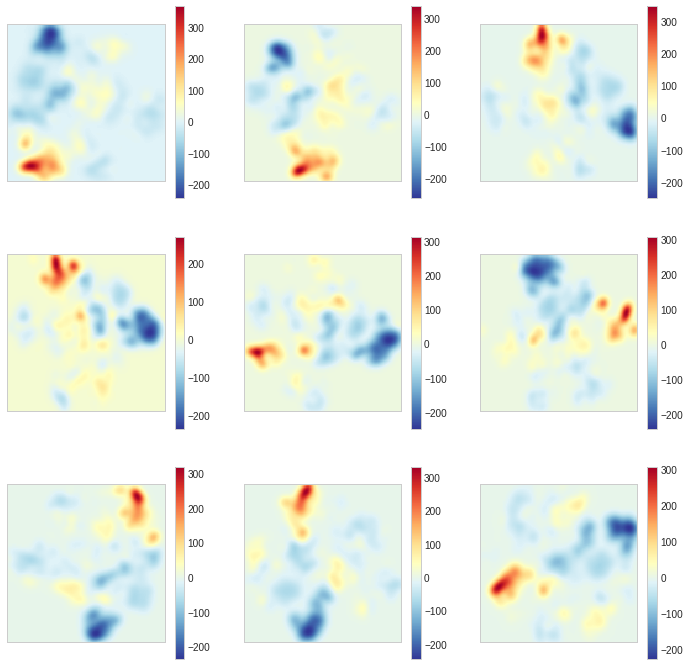

In [17]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(4*3,4*3))
axes = axes.ravel()

for idx, ax in enumerate(axes):
    img = img_train[indice[idx], :, :, 0]
    cax = ax.imshow(img, cmap="RdYlBu_r", origin='lower')
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(cax, ax=ax)
pass

# Build model

In [18]:
input_shape = (128, 128, 14)
n_class     = 3

In [21]:
### set model
np.random.seed(123)
model = Sequential()

### conv layer
model.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(layers.AveragePooling2D())

model.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(layers.AveragePooling2D())

### fully connected layer
model.add(layers.Flatten())
model.add(layers.Dense(units=120,     activation='relu'))
model.add(layers.Dense(units=84,      activation='relu'))
model.add(layers.Dense(units=n_class, activation='softmax'))

### compile the model
adam = Adam(lr=0.0001)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [22]:
%%time
### Train the model
history_lenet = model.fit(
    img_train, 
    y_train,
    epochs = 20,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 270 samples, validate on 60 samples
Epoch 1/20
270/270 [==============================] - 1s 5ms/step - loss: 8.7720 - acc: 0.3852 - val_loss: 10.2392 - val_acc: 0.3500
Epoch 2/20
270/270 [==============================] - 0s 1ms/step - loss: 8.7620 - acc: 0.3852 - val_loss: 8.3445 - val_acc: 0.3833
Epoch 3/20
270/270 [==============================] - 0s 2ms/step - loss: 6.5858 - acc: 0.5037 - val_loss: 7.1617 - val_acc: 0.4167
Epoch 4/20
270/270 [==============================] - 0s 1ms/step - loss: 5.0191 - acc: 0.5778 - val_loss: 5.4145 - val_acc: 0.5167
Epoch 5/20
270/270 [==============================] - 0s 1ms/step - loss: 3.0434 - acc: 0.7259 - val_loss: 5.9581 - val_acc: 0.5000
Epoch 6/20
270/270 [==============================] - 0s 2ms/step - loss: 1.8604 - acc: 0.8407 - val_loss: 4.5381 - val_acc: 0.5667
Epoch 7/20
270/270 [==============================] - 0s 1ms/step - loss: 1.3480 - acc: 0.9000 - val_loss: 3.4721 - val_acc: 0.6167
Epoch 8/20
270/270 [==========

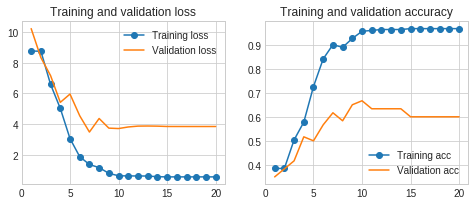

In [23]:
history = history_lenet
### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     'o-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss')
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      'o-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy')
ax.legend()

plt.show()

In [93]:
input_shape = (128, 128, 14)
n_class     = 3

In [105]:
### set model
np.random.seed(123)
model = Sequential()

model.add(layers.Conv2D(64, (3, 3), input_shape=input_shape, padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(4096,    activation='relu'))
model.add(layers.Dense(n_class, activation='softmax'))

### compile the model
adam = Adam(lr=0.0001)
model.compile(
    optimizer=adam,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [106]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_69 (Conv2D)           (None, 128, 128, 64)      8128      
_________________________________________________________________
conv2d_70 (Conv2D)           (None, 128, 128, 64)      36928     
_________________________________________________________________
max_pooling2d_23 (MaxPooling (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_71 (Conv2D)           (None, 64, 64, 128)       73856     
_________________________________________________________________
conv2d_72 (Conv2D)           (None, 64, 64, 128)       147584    
_________________________________________________________________
max_pooling2d_24 (MaxPooling (None, 32, 32, 128)       0         
_________________________________________________________________
conv2d_73 (Conv2D)           (None, 32, 32, 256)       295168    
__________

In [107]:
%%time
### Train the model
history = model.fit(
    img_train, 
    y_train,
    epochs = 50,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 270 samples, validate on 60 samples
Epoch 1/50
270/270 [==============================] - 6s 22ms/step - loss: 1.2773 - acc: 0.3296 - val_loss: 1.0980 - val_acc: 0.3333
Epoch 2/50
270/270 [==============================] - 2s 8ms/step - loss: 1.0873 - acc: 0.3333 - val_loss: 0.9166 - val_acc: 0.4833
Epoch 3/50
270/270 [==============================] - 2s 8ms/step - loss: 0.8369 - acc: 0.6148 - val_loss: 0.6530 - val_acc: 0.7167
Epoch 4/50
270/270 [==============================] - 2s 8ms/step - loss: 0.6184 - acc: 0.6259 - val_loss: 0.4744 - val_acc: 0.6667
Epoch 5/50
270/270 [==============================] - 2s 8ms/step - loss: 0.5168 - acc: 0.6370 - val_loss: 0.5087 - val_acc: 0.6667
Epoch 6/50
270/270 [==============================] - 2s 8ms/step - loss: 0.4981 - acc: 0.6852 - val_loss: 0.4751 - val_acc: 0.6667
Epoch 7/50
270/270 [==============================] - 2s 8ms/step - loss: 0.4724 - acc: 0.6444 - val_loss: 0.4733 - val_acc: 0.6667
Epoch 8/50
270/270 [==========

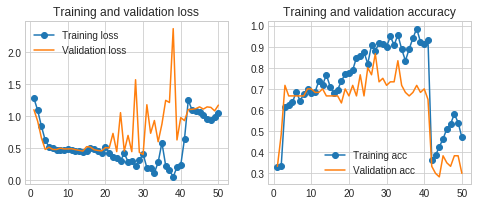

In [108]:
### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     'o-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss')
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      'o-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy')
ax.legend()

plt.show()

In [112]:
import numpy as np
from keras import layers
from keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from keras.models import Model, load_model
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
#import pydot
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
from keras.utils import plot_model
#from resnets_utils import *
from keras.initializers import glorot_uniform
import scipy.misc
from matplotlib.pyplot import imshow
%matplotlib inline

import keras.backend as K
K.set_image_data_format('channels_last')
K.set_learning_phase(1)

In [113]:
def identity_block(X, f, filters, stage, block):
    """
    Implementation of the identity block as defined in Figure 3
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    
    Returns:
    X -- output of the identity block, tensor of shape (n_H, n_W, n_C)
    """
    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value. You'll need this later to add back to the main path. 
    X_shortcut = X
    
    # First component of main path
    X = Conv2D(filters = F1, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    
    # Second component of main path (≈3 lines)
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    
    
    return X

In [114]:
def convolutional_block(X, f, filters, stage, block, s = 2):
    """
    Implementation of the convolutional block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used
    
    Returns:
    X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
    """
    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value
    X_shortcut = X


    ##### MAIN PATH #####
    # First component of main path 
    X = Conv2D(F1, (1, 1), strides = (s,s), name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    # Second component of main path (≈3 lines)
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)


    # Third component of main path (≈2 lines)
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X)


    ##### SHORTCUT PATH #### (≈2 lines)
    X_shortcut = Conv2D(filters = F3, kernel_size = (1, 1), strides = (s,s), padding = 'valid', name = conv_name_base + '1',
                        kernel_initializer = glorot_uniform(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(axis = 3, name = bn_name_base + '1')(X_shortcut)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    
    
    return X

In [115]:
def ResNet50(input_shape=(64, 64, 3), classes=6):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    Arguments:
    input_shape -- shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """

    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    ### START CODE HERE ###

    # Stage 3 (≈4 lines)
    X = convolutional_block(X, f = 3, filters = [128, 128, 512], stage = 3, block='a', s = 2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4 (≈6 lines)
    X = convolutional_block(X, f = 3, filters = [256, 256, 1024], stage = 4, block='a', s = 2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5 (≈3 lines)
    X = convolutional_block(X, f = 3, filters = [512, 512, 2048], stage = 5, block='a', s = 2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # AVGPOOL (≈1 line). Use "X = AveragePooling2D(...)(X)"
    X = AveragePooling2D((2,2), name="avg_pool")(X)

    ### END CODE HERE ###

    # output layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', name='fc' + str(classes), kernel_initializer = glorot_uniform(seed=0))(X)
    
    
    # Create model
    model = Model(inputs = X_input, outputs = X, name='ResNet50')

    return model

In [116]:
resnet = ResNet50(input_shape=input_shape, classes=n_class)

In [117]:
resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
resnet.fit(X_train, Y_train, epochs = 25, batch_size = 32)

In [118]:
%%time
### Train the model
history_resnet = resnet.fit(
    img_train, 
    y_train,
    epochs = 50,
    batch_size = 10,
    validation_data=(img_test, y_test))

Train on 270 samples, validate on 60 samples
Epoch 1/50
270/270 [==============================] - 16s 58ms/step - loss: 1.3970 - acc: 0.5519 - val_loss: 6.7956 - val_acc: 0.3333
Epoch 2/50
270/270 [==============================] - 3s 10ms/step - loss: 1.5754 - acc: 0.5926 - val_loss: 6.5565 - val_acc: 0.3667
Epoch 3/50
270/270 [==============================] - 3s 10ms/step - loss: 0.9905 - acc: 0.5778 - val_loss: 5.1740 - val_acc: 0.3333
Epoch 4/50
270/270 [==============================] - 3s 10ms/step - loss: 0.8353 - acc: 0.5852 - val_loss: 5.0428 - val_acc: 0.3167
Epoch 5/50
270/270 [==============================] - 3s 10ms/step - loss: 0.6809 - acc: 0.6704 - val_loss: 5.3455 - val_acc: 0.3667
Epoch 6/50
270/270 [==============================] - 3s 10ms/step - loss: 0.9386 - acc: 0.6333 - val_loss: 4.7068 - val_acc: 0.3333
Epoch 7/50
270/270 [==============================] - 3s 10ms/step - loss: 0.6247 - acc: 0.6852 - val_loss: 5.4474 - val_acc: 0.3667
Epoch 8/50
270/270 [===

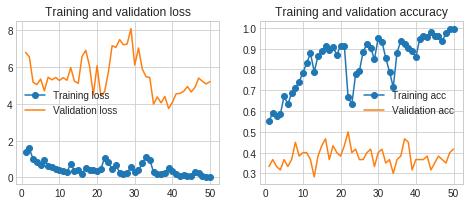

In [119]:
history = history_resnet
### extract the training / validation loss from fitting history
acc      = history.history['acc']
val_acc  = history.history['val_acc']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

### visualize the training / validation loss
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax = axes[0]
ax.plot(epochs, loss,     'o-', label='Training loss')
ax.plot(epochs, val_loss, '-',  label='Validation loss')
ax.set_title('Training and validation loss')
ax.legend()

ax = axes[1]
ax.plot(epochs, acc,      'o-', label='Training acc')
ax.plot(epochs, val_acc,  '-',  label='Validation acc')
ax.set_title('Training and validation accuracy')
ax.legend()

plt.show()